In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\_nonaromatic_2025_25295_CHO.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
0,Ethyl 3-ethoxy-cis-crotonate,C8H14O3,158,5331-73-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(/C)=C/C(=O)OCC,CHO
1,"Ethanone, 1-(3-methyloxiranyl)-",C5H8O2,100,17257-79-3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC1OC1C(C)=O,CHO
2,"2-Pentanone, 5-(1,2-propadienyloxy)-",C8H12O2,140,55702-69-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)CCCO[CH]=[C]=[CH2],CHO
6,"Oxalic acid, isohexyl propyl ester",C11H20O4,216,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCOC(=O)C(=O)OCCCC(C)C,CHO
7,"Oxalic acid, isohexyl pentyl ester",C13H24O4,244,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCOC(=O)C(=O)OCCCC(C)C,CHO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182295,"Propanedioic acid, (ethoxymethylene)-, diethyl...",C10H16O5,216,87-13-8,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC=C(C(=O)OCC)C(=O)OCC,CHO
182298,Diethyl n-hexadecylmalonate,C23H44O4,384,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCCCCCCCCCCCCCC(C(=O)OCC)C(=O)OCC,CHO
182305,Tetraethyl ethylenetetracarboxylate,C14H20O8,316,6174-95-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)C(C(=O)OCC)=C(C(=O)OCC)C(=O)OCC,CHO
182312,"Bicyclo[3.3.0]octan-3-one, 7-methylene-1,5-bis...",C15H20O5,280,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)C12CC(=C)CC1(CC(=O)C2)C(=O)OCC,CHO


In [4]:
# Create DEEPCHEM dataset
# First check if there are SMILES with a dot '.'
# These cannot be FEATURIZED and must be removed from the dataset.

X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
se = []
dr = [] # all these compounds should be removed
c=0
for i in y:
  se.append(sf.encoder(i))  # contains all SELFIES
  if '.' in sf.encoder(i):  # check if there is a dot in the selfies
    dr.append(c)
  c=c+1
# remove compounds which will give an error when featurizing
a=0
for i in dr:
  ms = ms.drop([ms.index[i-a]])
  a=a+1
# create new DeepChem dataset
X = ms.iloc[:,4:604]     # spectra
y = ms.iloc[:,605]       # smiles
ds = dc.data.DiskDataset.from_numpy(X,y)
ds

<DiskDataset X.shape: (np.int64(25295), np.int64(600)), y.shape: (np.int64(25295),), w.shape: (np.int64(25295),), task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[/-Ring1]': 3,
 '[/-Ring2]': 4,
 '[/C@@H1]': 5,
 '[/C@@]': 6,
 '[/C@H1]': 7,
 '[/C]': 8,
 '[/O]': 9,
 '[=Branch1]': 10,
 '[=Branch2]': 11,
 '[=CH0]': 12,
 '[=CH1]': 13,
 '[=CH2]': 14,
 '[=C]': 15,
 '[=N]': 16,
 '[=O]': 17,
 '[Branch1]': 18,
 '[Branch2]': 19,
 '[C@@H1]': 20,
 '[C@@]': 21,
 '[C@H1]': 22,
 '[C@]': 23,
 '[CH0]': 24,
 '[CH1]': 25,
 '[CH2]': 26,
 '[C]': 27,
 '[N]': 28,
 '[O]': 29,
 '[P]': 30,
 '[Ring1]': 31,
 '[Ring2]': 32,
 '[S]': 33,
 '[\\-Ring1]': 34,
 '[\\-Ring2]': 35,
 '[\\C@@H1]': 36,
 '[\\C]': 37,
 '[\\O]': 38,
 '[nop]': 39}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

----------------------------

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 22701
📦 Validation set size: 0
📦 Test set size: 2594


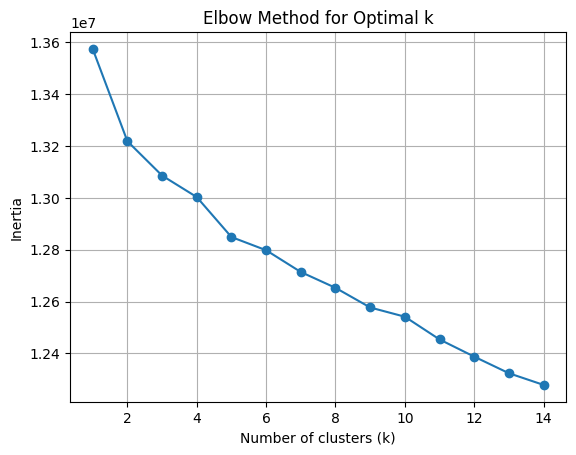

🔍 Elbow point detected at k = 5


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [10]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=5,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=5)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\

In [12]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(5):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (8669, 600)
Cluster 1 shape: (5068, 600)
Cluster 2 shape: (3770, 600)
Cluster 3 shape: (2588, 600)
Cluster 4 shape: (2606, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\

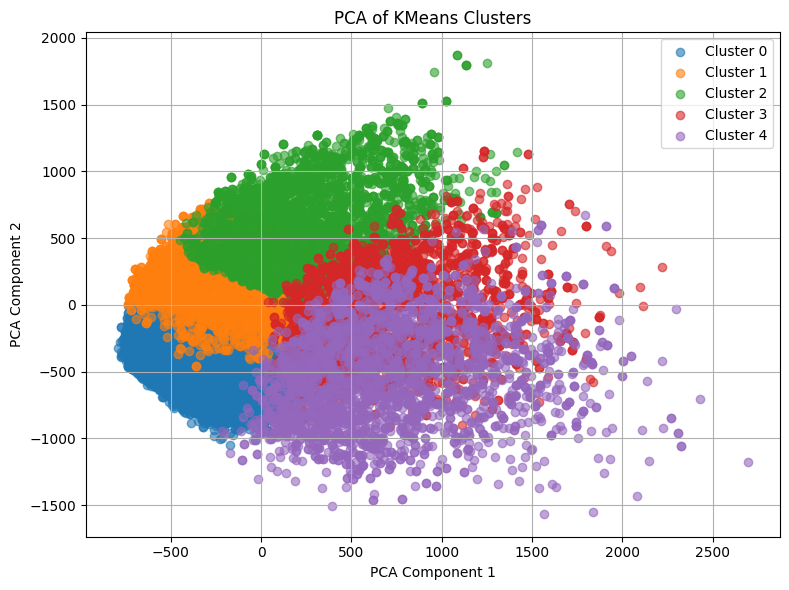

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=5)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [ ]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [ ]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")

✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\clus

Cluster 0: size = 1018, shape = (1018, 600)
Cluster 1: size = 571, shape = (571, 600)
Cluster 2: size = 408, shape = (408, 600)
Cluster 3: size = 287, shape = (287, 600)
Cluster 4: size = 310, shape = (310, 600)


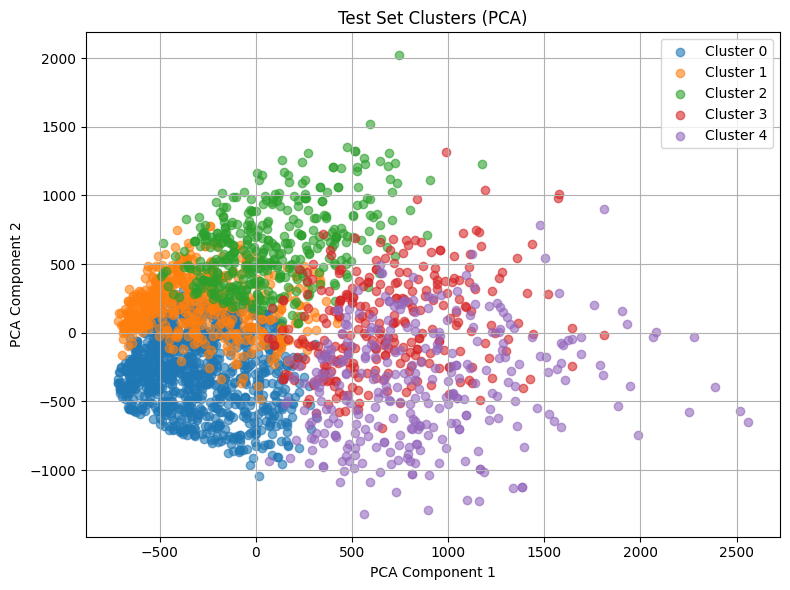

In [18]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(5):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.047945
Epoch 2/100 - Loss: 0.018831
Epoch 3/100 - Loss: 0.017543
Epoch 4/100 - Loss: 0.016709
Epoch 5/100 - Loss: 0.015676
Epoch 6/100 - Loss: 0.015180
Epoch 7/100 - Loss: 0.014161
Epoch 8/100 - Loss: 0.013643
Epoch 9/100 - Loss: 0.013032
Epoch 10/100 - Loss: 0.012509
Epoch 11/100 - Loss: 0.012077
Epoch 12/100 - Loss: 0.011531
Epoch 13/100 - Loss: 0.011139
Epoch 14/100 - Loss: 0.010980
Epoch 15/100 - Loss: 0.009673
Epoch 16/100 - Loss: 0.009631
Epoch 17/100 - Loss: 0.009316
Epoch 18/100 - Loss: 0.008962
Epoch 19/100 - Loss: 0.008692
Epoch 20/100 - Loss: 0.008303
Epoch 21/100 - Loss: 0.008096
Epoch 22/100 - Loss: 0.008130
Epoch 23/100 - Loss: 0.005547
Epoch 24/100 - Loss: 0.007078
Epoch 25/100 - Loss: 0.006847
Epoch 26/100 - Loss: 0.006771
Epoch 27/100 - Loss: 0.006617
Epoch 28/100 - Loss: 0.006425
Epoch 29/100 - Loss: 0.006432
Epoch 30/100 - Loss: 0.005770
Epoch 31/100 - Loss: 0.005766
Epoch 32/100 - Loss: 0.005724
Epoch 33/100 - Loss: 0.005680
Epoch 34/100 - Loss

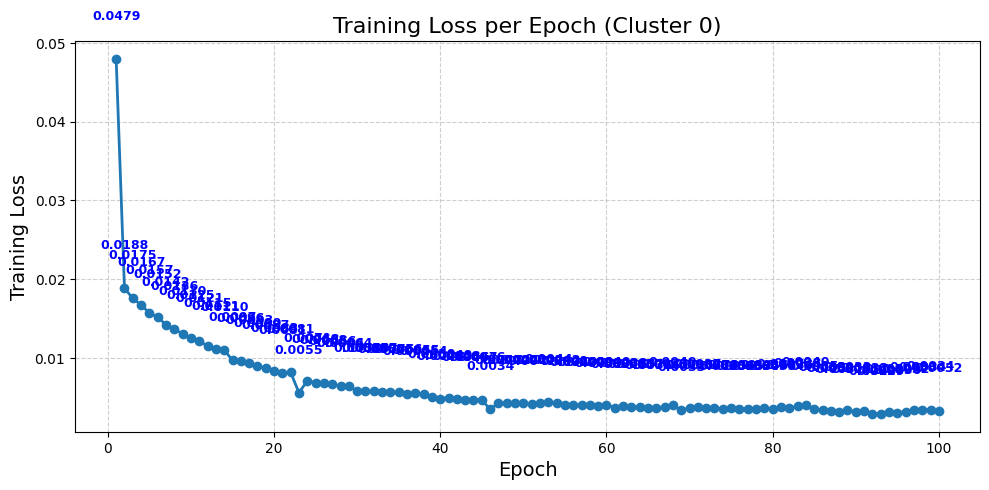

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\models_\model0000


In [7]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [8]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [ ]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (1018, 3640, 2)
Example prediction: [[1.00000000e+00 2.03022763e-17]
 [1.00000000e+00 7.59748328e-22]
 [1.00000000e+00 8.01573001e-22]
 ...
 [1.00000000e+00 1.03786484e-17]
 [1.00000000e+00 1.04961484e-16]
 [1.32920118e-19 1.00000000e+00]]


In [10]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [11]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [12]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: O=COCCC1OC1 | True: O=C1CCC2OC12 | Tanimoto: 0.220
[1] Pred: CCC1C(=O)COC1=O | True: CC1CC(=O)CC1=O | Tanimoto: 0.177
[2] Pred: O=C1COCC(=O)O1 | True: O=C1COCC(=O)O1 | Tanimoto: 1.000
[3] Pred: CC1CC(C)OCO1 | True: CC1CC(C)OCO1 | Tanimoto: 1.000
[4] Pred: O=C1CCCC(=O)C1 | True: O=C1CCCC(=O)C1 | Tanimoto: 1.000
[5] Pred: CC(C)=CCC\C(C)=C\C=O | True: CC(C)=CCC\C(C)=C/C=O | Tanimoto: 1.000
[6] Pred: CC(=C)C(=O)OCCCCCCOC(=O)C(C)=C | True: CC(=C)C(=O)OCCCCCCOC(=O)C(C)=C | Tanimoto: 1.000
[7] Pred: CC(C)=CCC\C(C)=C\C=O | True: CC(C)=CCC\C(C)=C\C=O | Tanimoto: 1.000
[8] Pred: CC/C=C/CC=O | True: CC/C=C/CC=O | Tanimoto: 1.000
[9] Pred: COC(=C)C(O)=O | True: CC(=C)C(O)=O | Tanimoto: 0.375
[10] Pred: C\C=C/C=O | True: C\C=C/C=O | Tanimoto: 1.000
[11] Pred: OC(C(O)C(=O)OCC=C)C(=O)OCC=C | True: OC(C(O)C(=O)OCC=C)C(=O)OCC=C | Tanimoto: 1.000
[12] Pred: CC1COCOC1 | True: C1CCOCC1 | Tanimoto: 0.242
[13] Pred: OCCO | True: CCCO | Tanimoto: 0.500
[14] Pred: C1OCOCO1 | True: C1OCOCO1 | Tanimot

Epoch 1/100 - Loss: 0.066923
Epoch 2/100 - Loss: 0.014953
Epoch 3/100 - Loss: 0.017119
Epoch 4/100 - Loss: 0.014551
Epoch 5/100 - Loss: 0.014793
Epoch 6/100 - Loss: 0.012457
Epoch 7/100 - Loss: 0.012731
Epoch 8/100 - Loss: 0.011769
Epoch 9/100 - Loss: 0.010929
Epoch 10/100 - Loss: 0.010146
Epoch 11/100 - Loss: 0.009400
Epoch 12/100 - Loss: 0.008655
Epoch 13/100 - Loss: 0.008038
Epoch 14/100 - Loss: 0.007418
Epoch 15/100 - Loss: 0.006822
Epoch 16/100 - Loss: 0.006319
Epoch 17/100 - Loss: 0.005781
Epoch 18/100 - Loss: 0.005355
Epoch 19/100 - Loss: 0.004914
Epoch 20/100 - Loss: 0.004573
Epoch 21/100 - Loss: 0.004237
Epoch 22/100 - Loss: 0.003942
Epoch 23/100 - Loss: 0.003612
Epoch 24/100 - Loss: 0.003569
Epoch 25/100 - Loss: 0.003229
Epoch 26/100 - Loss: 0.003129
Epoch 27/100 - Loss: 0.002902
Epoch 28/100 - Loss: 0.002716
Epoch 29/100 - Loss: 0.002625
Epoch 30/100 - Loss: 0.002510
Epoch 31/100 - Loss: 0.002323
Epoch 32/100 - Loss: 0.002210
Epoch 33/100 - Loss: 0.002021
Epoch 34/100 - Loss

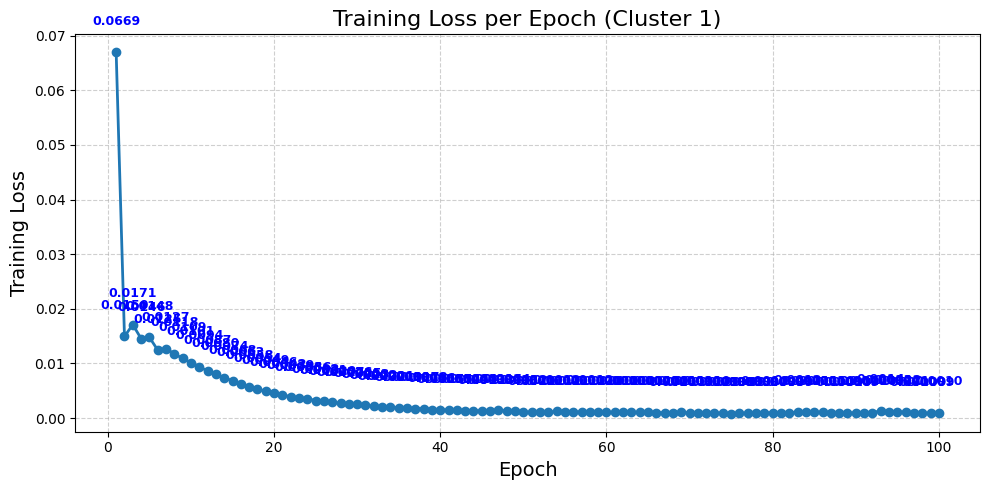

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\models_\model1111


In [13]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [14]:


import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (571, 3640, 2)
Example prediction: [[1.0000000e+00 2.9086603e-21]
 [1.0000000e+00 7.0957758e-22]
 [1.0000000e+00 5.5098249e-20]
 ...
 [1.0000000e+00 1.9982406e-25]
 [1.0000000e+00 3.5670546e-22]
 [2.0943273e-20 1.0000000e+00]]
[0] Pred: CCOC(/C)=C/C(=O)OCC | True: CCOC(/C)=C/C(=O)OCC | Tanimoto: 1.000
[1] Pred: CC\C=C(/C)C(C)O | True: CC\C=C(/C)C(C)O | Tanimoto: 1.000
[2] Pred: CC(=O)CC(=O)OCCO | True: CC(=O)CC(=O)OCCO | Tanimoto: 1.000
[3] Pred: CCCCCCOC(C)CCCCC | True: CCCCCCOC(C)CCCCC | Tanimoto: 1.000
[4] Pred: CCC(C)(O)CC(O)=O | True: CCC(C)(O)CC(O)=O | Tanimoto: 1.000
[5] Pred: CC(=O)CCCCCCCOC1CCCCO1 | True: CC(=O)CCCCCCCOC1CCCCO1 | Tanimoto: 1.000
[6] Pred: CC1(O)OC2(C)CCC1(C)OC2(C)O | True: CC1(O)OC2(C)CCC1(C)OC2(C)O | Tanimoto: 1.000
[7] Pred: CC(=O)CCCOCCCC(C)=O | True: CC(=O)CCCOCCCC(C)=O | Tanimoto: 1.000
[8] Pred: CCCCC(C)C(O)=O | True: CCCC(C)(C)C(O)=O | Tanimoto: 0.633
[9] Pred: CC(O)=CC(=O)CCCC(C)=C | True: CC(O)=CC(=O)CCCC(C)=C | Tanimoto: 1.000
[10

Epoch 1/100 - Loss: 0.082028
Epoch 2/100 - Loss: 0.014261
Epoch 3/100 - Loss: 0.012554
Epoch 4/100 - Loss: 0.011770
Epoch 5/100 - Loss: 0.010867
Epoch 6/100 - Loss: 0.009923
Epoch 7/100 - Loss: 0.009235
Epoch 8/100 - Loss: 0.008132
Epoch 9/100 - Loss: 0.007878
Epoch 10/100 - Loss: 0.007247
Epoch 11/100 - Loss: 0.006715
Epoch 12/100 - Loss: 0.006239
Epoch 13/100 - Loss: 0.005800
Epoch 14/100 - Loss: 0.005360
Epoch 15/100 - Loss: 0.005017
Epoch 16/100 - Loss: 0.004447
Epoch 17/100 - Loss: 0.004313
Epoch 18/100 - Loss: 0.004124
Epoch 19/100 - Loss: 0.003899
Epoch 20/100 - Loss: 0.003575
Epoch 21/100 - Loss: 0.003312
Epoch 22/100 - Loss: 0.003132
Epoch 23/100 - Loss: 0.002966
Epoch 24/100 - Loss: 0.002689
Epoch 25/100 - Loss: 0.002710
Epoch 26/100 - Loss: 0.002534
Epoch 27/100 - Loss: 0.002486
Epoch 28/100 - Loss: 0.002274
Epoch 29/100 - Loss: 0.002172
Epoch 30/100 - Loss: 0.002047
Epoch 31/100 - Loss: 0.002022
Epoch 32/100 - Loss: 0.001939
Epoch 33/100 - Loss: 0.001837
Epoch 34/100 - Loss

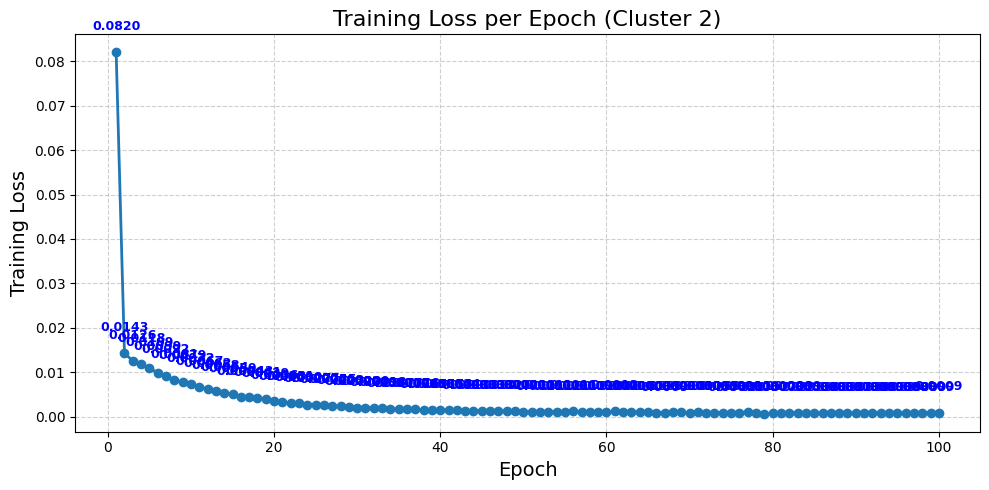

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\models_\model2222


In [15]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

# Ensure y is 2D
if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [ ]:

import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_1
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])
evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (408, 3640, 2)
Example prediction: [[1.0000000e+00 4.7243573e-13]
 [1.0000000e+00 4.2325046e-13]
 [1.0000000e+00 9.2829466e-13]
 ...
 [1.0000000e+00 1.7809894e-12]
 [1.0000000e+00 6.1017247e-10]
 [1.4761894e-10 1.0000000e+00]]
[0] Pred: OC1C2OCC(O2)C3OC13 | True: OC1C2OCC(O2)C3OC13 | Tanimoto: 1.000
[1] Pred: CCCCC(CC)COC(C)=O | True: CCCCC(CC)COC(C)=O | Tanimoto: 1.000
[2] Pred: CCCCCCCCCCCCCCCCCC(O)=O | True: CCCCCCCCCCCCCCCCCC(O)=O | Tanimoto: 1.000
[3] Pred: CCC(CC)CCCCCCCCCCCCCC(=O)OC | True: CCC(CC)CCCCCCCCCCCCCC(=O)OC | Tanimoto: 1.000
[4] Pred: CCCCCCOC(=O)CCCCCCCC(=O)OCCCCCC | True: CCCCCCOC(=O)CCCCCCCC(=O)OCCCCCC | Tanimoto: 1.000
[5] Pred: CCCCC(=O)CCC | True: CCCCC(=O)CCC | Tanimoto: 1.000
[6] Pred: CCCCCCCCCCCCCCCCCCCCC(C)C=O | True: CCCCCCCCCCCCCCCCCCCCCOC(C)=O | Tanimoto: 0.214
[7] Pred: CCCCCCCCCCCCCCCCCCCCCCCCOC=O | True: CCCCCCCCCCCCCCCCCCCCCCCOC(C)=O | Tanimoto: 0.730
[8] Pred: CCCCCCCCCCCC(=O)OCCCCCC(C)C | True: CCCCCCCCCCCC(=O)OCCCCCC(C)C | Tani

Epoch 1/100 - Loss: 0.123543
Epoch 2/100 - Loss: 0.015819
Epoch 3/100 - Loss: 0.014322
Epoch 4/100 - Loss: 0.013169
Epoch 5/100 - Loss: 0.012586
Epoch 6/100 - Loss: 0.011766
Epoch 7/100 - Loss: 0.011091
Epoch 8/100 - Loss: 0.010309
Epoch 9/100 - Loss: 0.009782
Epoch 10/100 - Loss: 0.009175
Epoch 11/100 - Loss: 0.008543
Epoch 12/100 - Loss: 0.007952
Epoch 13/100 - Loss: 0.007396
Epoch 14/100 - Loss: 0.006920
Epoch 15/100 - Loss: 0.006338
Epoch 16/100 - Loss: 0.005904
Epoch 17/100 - Loss: 0.005531
Epoch 18/100 - Loss: 0.005046
Epoch 19/100 - Loss: 0.004732
Epoch 20/100 - Loss: 0.004444
Epoch 21/100 - Loss: 0.004136
Epoch 22/100 - Loss: 0.003790
Epoch 23/100 - Loss: 0.003589
Epoch 24/100 - Loss: 0.003391
Epoch 25/100 - Loss: 0.003210
Epoch 26/100 - Loss: 0.003024
Epoch 27/100 - Loss: 0.002881
Epoch 28/100 - Loss: 0.002671
Epoch 29/100 - Loss: 0.002540
Epoch 30/100 - Loss: 0.002346
Epoch 31/100 - Loss: 0.002236
Epoch 32/100 - Loss: 0.002057
Epoch 33/100 - Loss: 0.001961
Epoch 34/100 - Loss

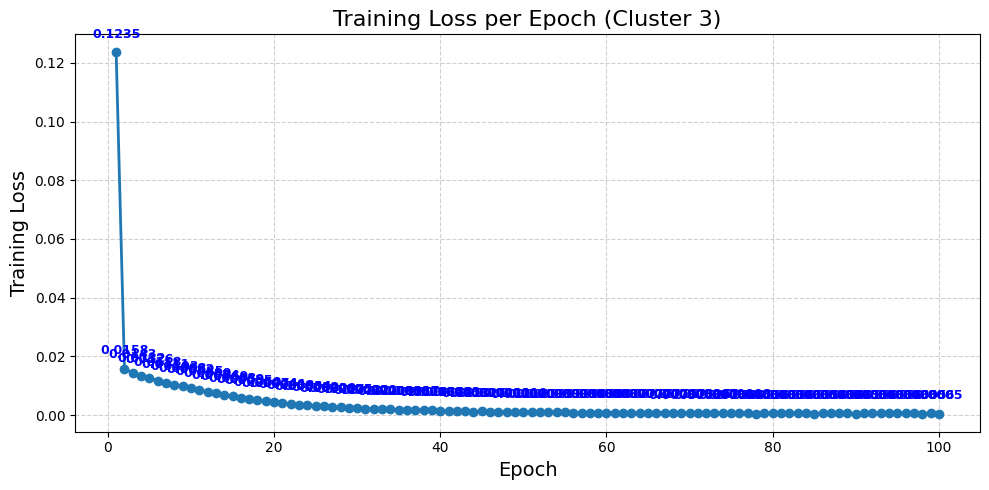

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\models_\model_cluster3


In [17]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 3 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_3.pkl", "rb") as f:
    X_cluster3 = pickle.load(f)

cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_3_indices.npy")
y_cluster3 = train_dataset.y[cluster_3_indices]

# Ensure y is 2D
if len(y_cluster3.shape) == 1:
    y_cluster3 = y_cluster3.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_3 = dc.data.NumpyDataset(X=np.array(X_cluster3), y=np.array(y_cluster3))

# === Model config
n_tasks = train_dataset_3.y.shape[1]
n_features = train_dataset_3.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_3 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\models_\model_cluster3"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_3.fit(train_dataset_3, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 3)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_3.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [18]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 3 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3.pkl", "rb") as f:
    X_test_cluster3 = pickle.load(f)

# === Load corresponding indices
test_cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster3 = test_dataset.y[test_cluster_3_indices]

# Ensure labels are 2D
if len(y_test_cluster3.shape) == 1:
    y_test_cluster3 = y_test_cluster3.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 3
test_dataset_3 = dc.data.NumpyDataset(X=np.array(X_test_cluster3), y=np.array(y_test_cluster3))

# === Predict using the trained model_3
predictions_3 = model_3.predict(test_dataset_3)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_3.shape)
print("Example prediction:", predictions_3[0])

# === Evaluate
evaluate_flat_predictions(predictions_3, test_dataset_3, itos, sf, cutoff=0.5)


✅ Prediction shape: (287, 3640, 2)
Example prediction: [[9.9999988e-01 1.1627484e-07]
 [9.9999964e-01 3.0389180e-07]
 [9.9999988e-01 1.6100053e-07]
 ...
 [1.0000000e+00 4.5837671e-09]
 [9.9999905e-01 9.1719471e-07]
 [3.3859491e-09 1.0000000e+00]]
[0] Pred: CCCCCCCC/C=C/CCCCOC(C)=O | True: CCCCCCCC/C=C/CCCCOC(C)=O | Tanimoto: 1.000
[1] Pred: CC1CC\C=C/CC\C=C/CCC1O | True: CC1CC\C=C/CC\C=C/CCC1O | Tanimoto: 1.000
[2] Pred: CCCCCC\C=C/CCCCOC(C)=O | True: CCCCCC\C=C/CCCCOC(C)=O | Tanimoto: 1.000
[3] Pred: CC1(C)CCCC2(C)C1CCC3(C)OC(=O)CCC23 | True: CC1(C)CCCC2(C)C1CCC3(C)OC(=O)CCC23 | Tanimoto: 1.000
[4] Pred: CCCCCCC#CC(C)O | True: CCCCCCC#CC(C)O | Tanimoto: 1.000
[5] Pred: CCCC\C=C/C=C\CCC1CCC(=O)C1 | True: CCCC\C=C/C=C\CCC1CCC(=O)C1 | Tanimoto: 1.000
[6] Pred: C[C@H1](CCC=C(C)C)[C@H1]1CC[C@H1]2[C@@H1]3CC[C@H1]4CCCC[C@]4(C)[C@H1]3CC(=O)[C@]12C | True: C[C@H1](CCC=C(C)C)[C@H1]1CC[C@H1]2[C@@H1]3CC[C@H1]4CCCC[C@]4(C)[C@H1]3CC(=O)[C@]12C | Tanimoto: 1.000
[7] Pred: CC(C(O)=O)C(C)(CCC=C(C)C)C=

Epoch 1/100 - Loss: 0.138845
Epoch 2/100 - Loss: 0.027577
Epoch 3/100 - Loss: 0.025411
Epoch 4/100 - Loss: 0.022000
Epoch 5/100 - Loss: 0.022696
Epoch 6/100 - Loss: 0.021495
Epoch 7/100 - Loss: 0.020362
Epoch 8/100 - Loss: 0.018798
Epoch 9/100 - Loss: 0.018300
Epoch 10/100 - Loss: 0.017208
Epoch 11/100 - Loss: 0.016273
Epoch 12/100 - Loss: 0.015313
Epoch 13/100 - Loss: 0.014464
Epoch 14/100 - Loss: 0.013550
Epoch 15/100 - Loss: 0.010565
Epoch 16/100 - Loss: 0.011902
Epoch 17/100 - Loss: 0.011137
Epoch 18/100 - Loss: 0.010461
Epoch 19/100 - Loss: 0.009897
Epoch 20/100 - Loss: 0.009169
Epoch 21/100 - Loss: 0.008587
Epoch 22/100 - Loss: 0.008047
Epoch 23/100 - Loss: 0.007511
Epoch 24/100 - Loss: 0.007037
Epoch 25/100 - Loss: 0.006476
Epoch 26/100 - Loss: 0.003996
Epoch 27/100 - Loss: 0.005730
Epoch 28/100 - Loss: 0.005392
Epoch 29/100 - Loss: 0.005242
Epoch 30/100 - Loss: 0.004757
Epoch 31/100 - Loss: 0.004522
Epoch 32/100 - Loss: 0.004274
Epoch 33/100 - Loss: 0.004072
Epoch 34/100 - Loss

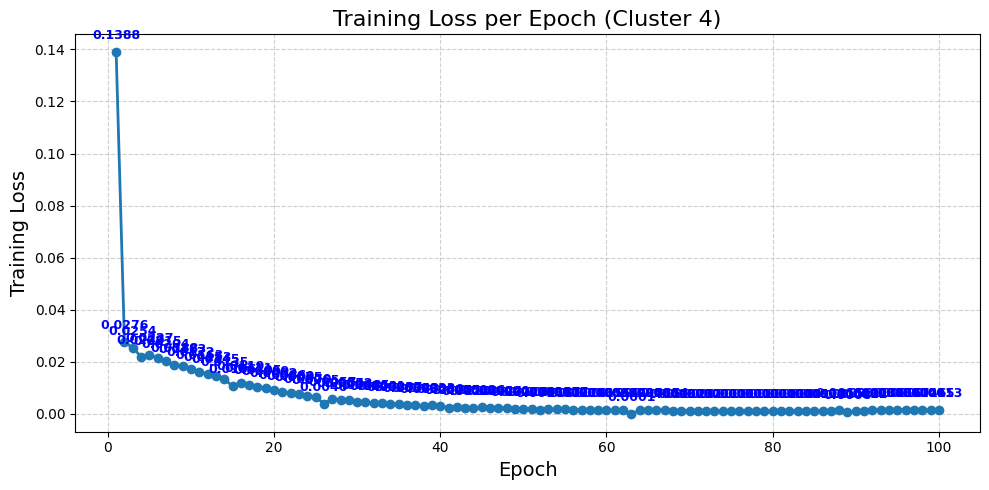

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\models_\model_cluster4


In [19]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 4 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_4.pkl", "rb") as f:
    X_cluster4 = pickle.load(f)

cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_4_indices.npy")
y_cluster4 = train_dataset.y[cluster_4_indices]

# Ensure y is 2D
if len(y_cluster4.shape) == 1:
    y_cluster4 = y_cluster4.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_4 = dc.data.NumpyDataset(X=np.array(X_cluster4), y=np.array(y_cluster4))

# === Model config
n_tasks = train_dataset_4.y.shape[1]
n_features = train_dataset_4.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_4 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\models_\model_cluster4"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_4.fit(train_dataset_4, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 4)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_4.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("\u2705 Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [20]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 4 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4.pkl", "rb") as f:
    X_test_cluster4 = pickle.load(f)

# === Load corresponding indices
test_cluster_4_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_4_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster4 = test_dataset.y[test_cluster_4_indices]

# Ensure labels are 2D
if len(y_test_cluster4.shape) == 1:
    y_test_cluster4 = y_test_cluster4.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 4
test_dataset_4 = dc.data.NumpyDataset(X=np.array(X_test_cluster4), y=np.array(y_test_cluster4))

# === Predict using the trained model_4 (make sure model_4 is loaded/trained)
predictions_4 = model_4.predict(test_dataset_4)

# === Inspect prediction shape and an example
print("✅ Prediction shape:", predictions_4.shape)
print("Example prediction:", predictions_4[0])

# === Evaluate
evaluate_flat_predictions(predictions_4, test_dataset_4, itos, sf, cutoff=0.5)


✅ Prediction shape: (310, 3640, 2)
Example prediction: [[9.9999571e-01 4.3393479e-06]
 [9.9999249e-01 7.5317530e-06]
 [9.9999976e-01 2.0070114e-07]
 ...
 [9.9999988e-01 7.4010003e-08]
 [9.9999952e-01 4.6842706e-07]
 [1.8348176e-07 9.9999976e-01]]
[0] Pred: CCCCCCCCCCCCC#CC#CCCCCCCCCC(O)=O | True: CCCCCCCCCCCCC#CC#CCCCCCCCCC(O)=O | Tanimoto: 1.000
[1] Pred: CCCCCCCCCCC#CCC#CCCCCCCCCC(O)=O | True: CCCCCCCCCCC#CC#CCCCCCCCCC(O)=O | Tanimoto: 0.915
[2] Pred: CC(=O)[C@H1]1CC[C@@]2(O)[C@]3(O)CC=C4C[C@H1](O)CC[C@]4(C)[C@H1]3[C@H1](O)[C@H1](O)[C@]12C | True: CC(=O)[C@H1]1CC[C@@]2(O)[C@]3(O)CC=C4C[C@H1](O)CC[C@]4(C)[C@H1]3[C@H1](O)[C@H1](O)[C@]12C | Tanimoto: 1.000
[3] Pred: CC1(C)OC2CC3=CCCCC3C(=O)C2O1 | True: CC1(C)OC2CC3=CCCCC3C(=O)C2O1 | Tanimoto: 1.000
[4] Pred: CC(=O)OCC=C(C)CCC=C(C)CCC(O)C(C)(C)O | True: CC(=O)OCC=C(C)CCC=C(C)CCC(O)C(C)(C)O | Tanimoto: 1.000
[5] Pred: CC(CCC=C(C)C)C1CCC2(C)C3C(C(=O)CC12C)C4(C)CCC(OC(C)=O)C(C)(C)C4CC3=O | True: CC(CCC=C(C)C)C1CCC2(C)C3C(C(=O)CC12C)C4(C)CCC

--------------------------------------------------------------

In [8]:
import os
import pickle
import glob
import numpy as np
from sklearn.utils import resample

# === YOUR PATHS ===
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with seed 123\kmeans_model"
cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset"
bootstrap_dir = os.path.join(cluster_dir, "bootstrap")

# === PARAMETERS ===
n_bootstrap = 3
random_seed = 123

# === Ensure output directory exists ===
os.makedirs(bootstrap_dir, exist_ok=True)

# === Bootstrap sampling function that also saves indices ===
def bootstrap_cluster_data_with_indices(data, n_iterations=100, sample_size=None, random_seed=42):
    if sample_size is None:
        sample_size = len(data)
    
    results = []
    for i in range(n_iterations):
        indices = np.random.RandomState(seed=random_seed + i).choice(
            len(data), size=sample_size, replace=True
        )
        sample = [data[idx] for idx in indices]
        results.append((sample, indices.tolist()))
    return results

# === Find cluster files ===
cluster_files = sorted(glob.glob(os.path.join(cluster_dir, "cluster_*.pkl")))
n_clusters = len(cluster_files)

print(f"🔍 Found {n_clusters} clusters in: {cluster_dir}")

# === Loop through each cluster and apply bootstrapping ===
for cluster_id in range(n_clusters):
    cluster_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")

    # Load cluster data
    with open(cluster_path, "rb") as f:
        cluster_data = pickle.load(f)

    print(f"🔁 Bootstrapping Cluster {cluster_id} with {len(cluster_data)} entries...")

    # Apply bootstrapping
    boot_samples_with_indices = bootstrap_cluster_data_with_indices(
        cluster_data,
        n_iterations=n_bootstrap,
        sample_size=len(cluster_data),
        random_seed=random_seed
    )

    # Save both data and indices for each bootstrap
    output_path = os.path.join(bootstrap_dir, f"cluster_{cluster_id}_bootstrap.pkl")
    with open(output_path, "wb") as f:
        pickle.dump(boot_samples_with_indices, f)

    print(f"✅ Saved {n_bootstrap} bootstrap samples + indices for Cluster {cluster_id} to:")
    print(f"   {output_path}")


🔍 Found 5 clusters in: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset
🔁 Bootstrapping Cluster 0 with 8669 entries...
✅ Saved 3 bootstrap samples + indices for Cluster 0 to:
   C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\bootstrap\cluster_0_bootstrap.pkl
🔁 Bootstrapping Cluster 1 with 5068 entries...
✅ Saved 3 bootstrap samples + indices for Cluster 1 to:
   C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\bootstrap\cluster_1_bootstrap.pkl
🔁 Bootstrapping Cluster 2 with 3770 entries...
✅ Saved 3 bootstrap samples + indices for Cluster 2 to:


In [9]:
import os
import pickle
import glob

# === Path to where your bootstrapped clusters are saved ===
bootstrap_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\bootstrap"

# === Find all bootstrap cluster files ===
bootstrap_files = sorted(glob.glob(os.path.join(bootstrap_dir, "cluster_*_bootstrap.pkl")))

print(f"🔍 Found {len(bootstrap_files)} bootstrapped cluster files.\n")

for file_path in bootstrap_files:
    cluster_id = os.path.basename(file_path).split("_")[1]
    
    with open(file_path, "rb") as f:
        boot_samples = pickle.load(f)
    
    n_samples = len(boot_samples)
    sample_size = len(boot_samples[0]) if boot_samples else 0

    print(f"📂 Cluster {cluster_id}: {n_samples} bootstrap samples × {sample_size} instances each")


🔍 Found 5 bootstrapped cluster files.

📂 Cluster 0: 3 bootstrap samples × 2 instances each
📂 Cluster 1: 3 bootstrap samples × 2 instances each
📂 Cluster 2: 3 bootstrap samples × 2 instances each
📂 Cluster 3: 3 bootstrap samples × 2 instances each
📂 Cluster 4: 3 bootstrap samples × 2 instances each


Epoch 1/150 - Loss: 0.038156
Epoch 2/150 - Loss: 0.018820
Epoch 3/150 - Loss: 0.017380
Epoch 4/150 - Loss: 0.016718
Epoch 5/150 - Loss: 0.015356
Epoch 6/150 - Loss: 0.014619
Epoch 7/150 - Loss: 0.013644
Epoch 8/150 - Loss: 0.012935
Epoch 9/150 - Loss: 0.011938
Epoch 10/150 - Loss: 0.010922
Epoch 11/150 - Loss: 0.010246
Epoch 12/150 - Loss: 0.009138
Epoch 13/150 - Loss: 0.008311
Epoch 14/150 - Loss: 0.007139
Epoch 15/150 - Loss: 0.005943
Epoch 16/150 - Loss: 0.005726
Epoch 17/150 - Loss: 0.005199
Epoch 18/150 - Loss: 0.004729
Epoch 19/150 - Loss: 0.004094
Epoch 20/150 - Loss: 0.003630
Epoch 21/150 - Loss: 0.003488
Epoch 22/150 - Loss: 0.003188
Epoch 23/150 - Loss: 0.002197
Epoch 24/150 - Loss: 0.002356
Epoch 25/150 - Loss: 0.002244
Epoch 26/150 - Loss: 0.002043
Epoch 27/150 - Loss: 0.002023
Epoch 28/150 - Loss: 0.001909
Epoch 29/150 - Loss: 0.001821
Epoch 30/150 - Loss: 0.001597
Epoch 31/150 - Loss: 0.001569
Epoch 32/150 - Loss: 0.001593
Epoch 33/150 - Loss: 0.001538
Epoch 34/150 - Loss

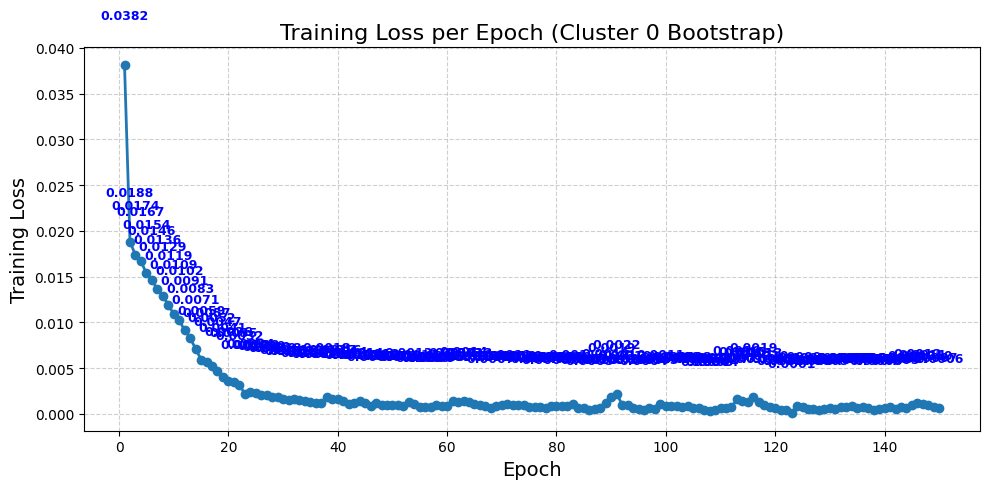

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\bootstrap_models\models_\model0


In [10]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load train_dataset externally (you must already have it loaded before this script)
# train_dataset = ...  # <--- ensure this is already defined

# === Load bootstrap data and indices for cluster_0
bootstrap_path = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\bootstrap\cluster_0_bootstrap.pkl"
with open(bootstrap_path, "rb") as f:
    bootstrap_samples = pickle.load(f)

# Select the first bootstrap sample (index 0); change index if needed
X_cluster0, indices_cluster0 = bootstrap_samples[0]

# Load cluster_0_indices to map bootstrap indices back to original dataset
cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")

# Map bootstrap indices to full dataset indices
full_indices = cluster_0_indices[indices_cluster0]
y_cluster0 = train_dataset.y[full_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [100, 1600, 1750,2000]
dropout_rate = 0.001
num_epochs = 150

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\bootstrap_models\models_\model0"
os.makedirs(model_dir, exist_ok=True)

# === Training loop
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0 Bootstrap)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [11]:

import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

In [12]:


if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])

itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


✅ Prediction shape: (1018, 3640, 2)
Example prediction: [[1.00000000e+00 1.21776895e-32]
 [1.00000000e+00 7.83283589e-34]
 [1.00000000e+00 6.82372731e-31]
 ...
 [1.00000000e+00 1.25703325e-33]
 [1.00000000e+00 5.77092752e-33]
 [1.22710222e-36 1.00000000e+00]]
[0] Pred: O=C1CCC2OC12 | True: O=C1CCC2OC12 | Tanimoto: 1.000
[1] Pred: CC1CC(=O)CC1=O | True: CC1CC(=O)CC1=O | Tanimoto: 1.000
[2] Pred: O=C1COCC(=O)O1 | True: O=C1COCC(=O)O1 | Tanimoto: 1.000
[3] Pred: CC1CC(C)OCO1 | True: CC1CC(C)OCO1 | Tanimoto: 1.000
[4] Pred: O=CC1C=CCC(=O)C1 | True: O=C1CCCC(=O)C1 | Tanimoto: 0.207
[5] Pred: CC(C)=CCC\C(C)=C/C=O | True: CC(C)=CCC\C(C)=C/C=O | Tanimoto: 1.000
[6] Pred: CC(CCCC)CCC=CC=C | True: CC(=C)C(=O)OCCCCCCOC(=O)C(C)=C | Tanimoto: 0.099
[7] Pred: CC(C)=CCC\C(C)=C/C=O | True: CC(C)=CCC\C(C)=C\C=O | Tanimoto: 1.000
[8] Pred: CC#CC(O)O | True: CC/C=C/CC=O | Tanimoto: 0.040
[9] Pred: CC(=C)C(O)=O | True: CC(=C)C(O)=O | Tanimoto: 1.000
[10] Pred: C\C=C/C=O | True: C\C=C/C=O | Tanimoto: 1.000

Epoch 1/100 - Loss: 0.065960
Epoch 2/100 - Loss: 0.014022
Epoch 3/100 - Loss: 0.016063
Epoch 4/100 - Loss: 0.012761
Epoch 5/100 - Loss: 0.012950
Epoch 6/100 - Loss: 0.010380
Epoch 7/100 - Loss: 0.010280
Epoch 8/100 - Loss: 0.008951
Epoch 9/100 - Loss: 0.008164
Epoch 10/100 - Loss: 0.007076
Epoch 11/100 - Loss: 0.006575
Epoch 12/100 - Loss: 0.005795
Epoch 13/100 - Loss: 0.005356
Epoch 14/100 - Loss: 0.004760
Epoch 15/100 - Loss: 0.004359
Epoch 16/100 - Loss: 0.003730
Epoch 17/100 - Loss: 0.003664
Epoch 18/100 - Loss: 0.003387
Epoch 19/100 - Loss: 0.003026
Epoch 20/100 - Loss: 0.002841
Epoch 21/100 - Loss: 0.002629
Epoch 22/100 - Loss: 0.002451
Epoch 23/100 - Loss: 0.002141
Epoch 24/100 - Loss: 0.002020
Epoch 25/100 - Loss: 0.001909
Epoch 26/100 - Loss: 0.001796
Epoch 27/100 - Loss: 0.001694
Epoch 28/100 - Loss: 0.001630
Epoch 29/100 - Loss: 0.001512
Epoch 30/100 - Loss: 0.001474
Epoch 31/100 - Loss: 0.001349
Epoch 32/100 - Loss: 0.001252
Epoch 33/100 - Loss: 0.001212
Epoch 34/100 - Loss

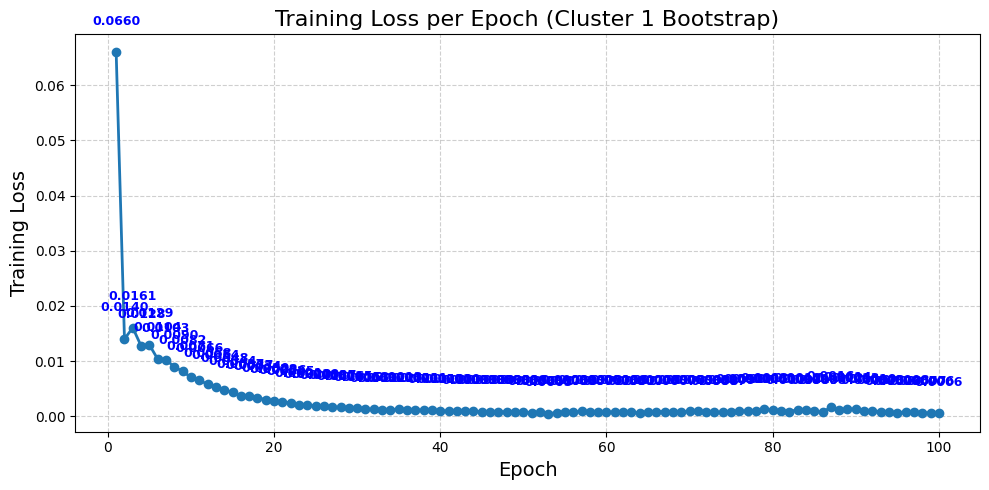

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\bootstrap_models\models_\model1


In [ ]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load bootstrap data and indices for cluster_1
bootstrap_path = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\bootstrap\cluster_1_bootstrap.pkl"
with open(bootstrap_path, "rb") as f:
    bootstrap_samples = pickle.load(f)

# Select the first bootstrap sample (index 0)
X_cluster1, indices_cluster1 = bootstrap_samples[0]

# Load cluster_1_indices to map bootstrap indices back to original dataset
cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")

# Map bootstrap indices to full dataset indices
full_indices = cluster_1_indices[indices_cluster1]
y_cluster1 = train_dataset.y[full_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\bootstrap_models\models_\model1"
os.makedirs(model_dir, exist_ok=True)

# === Training loop
losses = []
for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1 Bootstrap)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [54]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc
from rdkit import Chem, DataStructs
import selfies as sf  # ensure `selfies` is installed


# === Load test data for cluster 1
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

test_cluster_1_indices = np.load(
    r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_nonaromatic_2025_25295_CHO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy"
)
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Run predictions
predictions_1 = model_1.predict(test_dataset_1)
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])


# === Evaluation Function
def evaluate_flat_predictions(predictions, test_dataset, itos, sf_module, cutoff=0.5):
    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf_module.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf_module.decoder(true_selfie)
        except:
            true_smiles = ''

        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")




# === Finally, run the evaluation:
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (571, 3640, 2)
Example prediction: [[1.00000000e+00 2.02843637e-20]
 [1.00000000e+00 2.06640404e-17]
 [1.00000000e+00 1.59816904e-19]
 ...
 [1.00000000e+00 1.08671085e-17]
 [1.00000000e+00 2.15298466e-19]
 [7.44601694e-22 1.00000000e+00]]
[0] Pred: CCOC(/C)=C/C(=O)OCC | True: CCOC(/C)=C/C(=O)OCC | Tanimoto: 1.000
[1] Pred: CC\C=C(/C)C(C)O | True: CC\C=C(/C)C(C)O | Tanimoto: 1.000
[2] Pred: CC(=O)CC(=O)OCCO | True: CC(=O)CC(=O)OCCO | Tanimoto: 1.000
[3] Pred: CCCCCCOC(C)CCCCC | True: CCCCCCOC(C)CCCCC | Tanimoto: 1.000
[4] Pred: CCC(C)(O)CC(O)=O | True: CCC(C)(O)CC(O)=O | Tanimoto: 1.000
[5] Pred: CC(=O)CCCCCCCOC1CCCCO1 | True: CC(=O)CCCCCCCOC1CCCCO1 | Tanimoto: 1.000
[6] Pred: CC1(O)OC2(C)CCC1(C)OC2(C)O | True: CC1(O)OC2(C)CCC1(C)OC2(C)O | Tanimoto: 1.000
[7] Pred: CC(=O)CCCOCCCC(C)=O | True: CC(=O)CCCOCCCC(C)=O | Tanimoto: 1.000
[8] Pred: CCCC(C)(C)C(=O)OCCPCOCCC(C)CCOC(=O)CC(C)CCC | True: CCCC(C)(C)C(O)=O | Tanimoto: 0.341
[9] Pred: CC(O)=CC(=O)CCCC(C)=C | True: CC

------------------------------------------------------------